In [42]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('fifa_model_ready.csv')

In [3]:
df

,height_cm,weight_kg,preferred_foot,skill_moves,pace,shooting,passing,dribbling,defending,physic,...,attacking_heading_accuracy,skill_curve,skill_fk_accuracy,skill_long_passing,movement_agility,movement_balance,power_jumping,mentality_aggression,mentality_penalties,position
0,170,72,0,4,85.0,92.0,91.0,95.0,34.0,65.0,...,70,93,94,91,91,95,68,44,75,RW
1,185,81,1,4,78.0,92.0,79.0,86.0,44.0,82.0,...,90,79,85,70,77,82,85,81,90,ST
2,187,83,1,5,87.0,94.0,80.0,88.0,34.0,75.0,...,90,81,84,77,86,74,95,63,88,ST
3,175,68,1,5,91.0,83.0,86.0,94.0,37.0,63.0,...,63,88,87,81,96,84,64,63,93,LW
4,181,70,1,4,76.0,86.0,93.0,88.0,64.0,78.0,...,55,85,83,93,79,78,63,76,83,CM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16015,180,64,1,2,58.0,35.0,46.0,48.0,42.0,49.0,...,48,33,38,48,55,70,62,52,42,CDM
16016,175,70,1,2,59.0,39.0,50.0,46.0,41.0,51.0,...,46,53,31,50,64,69,47,49,44,CM
16017,178,72,1,2,60.0,37.0,45.0,49.0,41.0,52.0,...,43,37,37,49,58,59,57,51,39,CM
16018,173,66,1,2,68.0,46.0,36.0,48.0,15.0,42.0,...,40,36,34,33,72,73,50,34,49,ST


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16020 entries, 0 to 16019
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   height_cm                   16020 non-null  int64  
 1   weight_kg                   16020 non-null  int64  
 2   preferred_foot              16020 non-null  int64  
 3   skill_moves                 16020 non-null  int64  
 4   pace                        16020 non-null  float64
 5   shooting                    16020 non-null  float64
 6   passing                     16020 non-null  float64
 7   dribbling                   16020 non-null  float64
 8   defending                   16020 non-null  float64
 9   physic                      16020 non-null  float64
 10  attacking_crossing          16020 non-null  int64  
 11  attacking_heading_accuracy  16020 non-null  int64  
 12  skill_curve                 16020 non-null  int64  
 13  skill_fk_accuracy           160

In [9]:
le = LabelEncoder()
df['position'] = le.fit_transform(df['position'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16020 entries, 0 to 16019
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   height_cm                   16020 non-null  int64  
 1   weight_kg                   16020 non-null  int64  
 2   preferred_foot              16020 non-null  int64  
 3   skill_moves                 16020 non-null  int64  
 4   pace                        16020 non-null  float64
 5   shooting                    16020 non-null  float64
 6   passing                     16020 non-null  float64
 7   dribbling                   16020 non-null  float64
 8   defending                   16020 non-null  float64
 9   physic                      16020 non-null  float64
 10  attacking_crossing          16020 non-null  int64  
 11  attacking_heading_accuracy  16020 non-null  int64  
 12  skill_curve                 16020 non-null  int64  
 13  skill_fk_accuracy           160

In [11]:
X = df.drop(columns=["position"])
y = df["position"]

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [13]:
print(f'X_train shape: {X_train.shape} \nX_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape} \ny_test shape: {y_test.shape}')

X_train shape: (12816, 20) 
X_test shape: (3204, 20)
y_train shape: (12816,) 
y_test shape: (3204,)


In [15]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42
)

In [16]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6878901373283396
              precision    recall  f1-score   support

           0       0.51      0.49      0.50       217
           1       0.89      0.91      0.90       628
           2       0.64      0.60      0.62       319
           3       0.00      0.00      0.00        26
           4       0.63      0.77      0.69       408
           5       0.77      0.87      0.82       259
           6       0.36      0.35      0.36       186
           7       0.31      0.10      0.15        81
           8       0.00      0.00      0.00        33
           9       0.73      0.82      0.77       255
          10       0.32      0.34      0.33       193
          11       0.18      0.06      0.10        93
          12       0.00      0.00      0.00        34
          13       0.84      0.93      0.89       472

    accuracy                           0.69      3204
   macro avg       0.44      0.45      0.44      3204
weighted avg       0.65      0.69      0.67      32

C:\Users\Arup sarkar\.conda\envs\condaenv3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Arup sarkar\.conda\envs\condaenv3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Arup sarkar\.conda\envs\condaenv3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [19]:
print(le.classes_[3])   # which position is class 3
print(le.classes_[8])   # which position is class 8
print(le.classes_[12])  # which position is class 12

CF
LWB
RWB


In [21]:
smote = SMOTE(random_state=42)
X_train_resampled,y_train_resampled = smote.fit_resample(X_train,y_train)

In [22]:
model.fit(X_train_resampled, y_train_resampled)
y_pred = model.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6513732833957553
              precision    recall  f1-score   support

           0       0.53      0.55      0.54       217
           1       0.91      0.89      0.90       628
           2       0.61      0.64      0.63       319
           3       0.03      0.04      0.03        26
           4       0.68      0.67      0.67       408
           5       0.77      0.71      0.74       259
           6       0.34      0.24      0.28       186
           7       0.16      0.19      0.17        81
           8       0.10      0.18      0.13        33
           9       0.70      0.73      0.71       255
          10       0.31      0.27      0.29       193
          11       0.19      0.22      0.20        93
          12       0.13      0.21      0.16        34
          13       0.88      0.89      0.88       472

    accuracy                           0.65      3204
   macro avg       0.45      0.46      0.45      3204
weighted avg       0.66      0.65      0.65      32

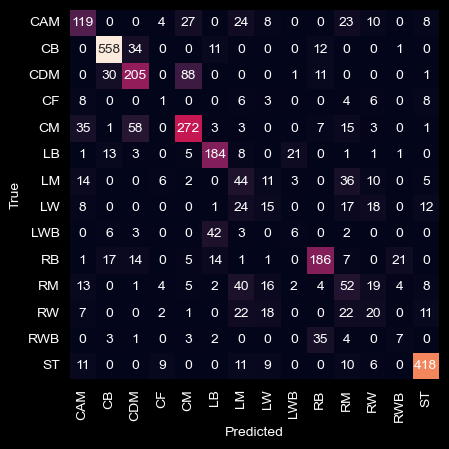

In [25]:
matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(matrix.T, square=True, annot=True, fmt='d', cbar=False, xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [29]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8]
}
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train_resampled, y_train_resampled)

print("Best Params:", xgb_search.best_params_)
print("Best f1_macro:", xgb_search.best_score_)


Best Params: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1}
Best f1_macro: 0.4533589855950756


In [30]:
best_model = xgb_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.6679151061173533
              precision    recall  f1-score   support

         CAM       0.53      0.53      0.53       217
          CB       0.90      0.90      0.90       628
         CDM       0.62      0.66      0.64       319
          CF       0.08      0.04      0.05        26
          CM       0.68      0.69      0.68       408
          LB       0.76      0.77      0.77       259
          LM       0.33      0.28      0.30       186
          LW       0.17      0.16      0.16        81
         LWB       0.08      0.06      0.07        33
          RB       0.70      0.82      0.76       255
          RM       0.25      0.26      0.25       193
          RW       0.26      0.22      0.23        93
         RWB       0.00      0.00      0.00        34
          ST       0.88      0.90      0.89       472

    accuracy                           0.67      3204
   macro avg       0.44      0.45      0.45      3204
weighted avg       0.65      0.67      0.66      32

In [36]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8]
}
lgbm = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
lgbm_search = RandomizedSearchCV(
    lgbm,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1
)
lgbm_search.fit(X_train, y_train)

,estimator,"LGBMClassifie...2, verbose=-1)"
,param_distributions,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,20
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [37]:
print("Best Params:", lgbm_search.best_params_)
print("Best F1 Macro:", lgbm_search.best_score_)

Best Params: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05}
Best F1 Macro: 0.453007460505507


In [38]:
best_lgbm = lgbm_search.best_estimator_
y_pred_lgbm = best_lgbm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm, target_names=le.classes_))

Accuracy: 0.66354556803995
              precision    recall  f1-score   support

         CAM       0.53      0.55      0.54       217
          CB       0.92      0.88      0.90       628
         CDM       0.60      0.68      0.64       319
          CF       0.14      0.15      0.15        26
          CM       0.66      0.65      0.66       408
          LB       0.77      0.81      0.79       259
          LM       0.33      0.21      0.25       186
          LW       0.13      0.15      0.14        81
         LWB       0.07      0.06      0.06        33
          RB       0.72      0.80      0.75       255
          RM       0.31      0.29      0.30       193
          RW       0.21      0.26      0.23        93
         RWB       0.15      0.15      0.15        34
          ST       0.89      0.89      0.89       472

    accuracy                           0.66      3204
   macro avg       0.46      0.47      0.46      3204
weighted avg       0.66      0.66      0.66      3204

In [40]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8]
}
lgbm = LGBMClassifier(random_state=42, verbose=-1)
lgbm_search_smote = RandomizedSearchCV(
    lgbm,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1
)
lgbm_search_smote.fit(X_train_resampled, y_train_resampled)

,estimator,"LGBMClassifie...2, verbose=-1)"
,param_distributions,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,20
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [41]:
print("Best Params:", lgbm_search_smote.best_params_)
print("Best F1 Macro:", lgbm_search_smote.best_score_)

best_lgbm_smote = lgbm_search_smote.best_estimator_
y_pred_lgbm_smote = best_lgbm_smote.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lgbm_smote))
print(classification_report(y_test, y_pred_lgbm_smote, target_names=le.classes_))

Best Params: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1}
Best F1 Macro: 0.9142805542007709
Accuracy: 0.66729088639201
              precision    recall  f1-score   support

         CAM       0.49      0.49      0.49       217
          CB       0.91      0.90      0.91       628
         CDM       0.62      0.66      0.64       319
          CF       0.14      0.08      0.10        26
          CM       0.66      0.66      0.66       408
          LB       0.78      0.78      0.78       259
          LM       0.31      0.27      0.29       186
          LW       0.18      0.17      0.18        81
         LWB       0.08      0.06      0.07        33
          RB       0.71      0.80      0.75       255
          RM       0.29      0.33      0.31       193
          RW       0.28      0.22      0.24        93
         RWB       0.09      0.03      0.04        34
          ST       0.87      0.90      0.89       472

    accuracy                           0.67      3204


In [43]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(random_state=42, verbose=-1))
])
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [4, 6, 8]
}
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1
)
search.fit(X_train,y_train)

,estimator,Pipeline(step...verbose=-1))])
,param_distributions,"{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [4, 6, ...], 'model__n_estimators': [100, 200, ...]}"
,n_iter,20
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [44]:
print("Best Params:", search.best_params_)
print("Best F1 Macro:", search.best_score_)

best_lgbm_smote2 = search.best_estimator_
y_pred_search = best_lgbm_smote2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_search))
print(classification_report(y_test, y_pred_search, target_names=le.classes_))

Best Params: {'model__n_estimators': 100, 'model__max_depth': 8, 'model__learning_rate': 0.05}
Best F1 Macro: 0.4583170109306309
Accuracy: 0.6629213483146067
              precision    recall  f1-score   support

         CAM       0.54      0.54      0.54       217
          CB       0.91      0.89      0.90       628
         CDM       0.64      0.66      0.65       319
          CF       0.05      0.08      0.06        26
          CM       0.68      0.67      0.67       408
          LB       0.76      0.74      0.75       259
          LM       0.36      0.25      0.29       186
          LW       0.14      0.15      0.14        81
         LWB       0.09      0.12      0.10        33
          RB       0.70      0.77      0.73       255
          RM       0.32      0.33      0.33       193
          RW       0.20      0.23      0.21        93
         RWB       0.18      0.18      0.18        34
          ST       0.89      0.89      0.89       472

    accuracy                  